In [14]:
import scomv
import stlearn as st
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import pandas as pd
import numpy as np
import anndata
import scanpy as sc
import seaborn as sns
from adjustText import adjust_text
from tqdm import tqdm

In [15]:
#!mkdir tutorial_data
#!mkdir tutorial_data/xenium_data
#!wget -P tutorial_data/xenium_data/ https://cf.10xgenomics.com/samples/xenium/preview/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_cell_feature_matrix.h5
#!wget -P tutorial_data/xenium_data/ https://cf.10xgenomics.com/samples/xenium/preview/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_cells.csv.gz

In [16]:
# Load Xenium data using stlearn
adata = st.ReadXenium(
    feature_cell_matrix_file="../tutorial_data/xenium_data/cell_feature_matrix.h5",
    cell_summary_file="../tutorial_data/xenium_data/cells.csv.gz",
    library_id="example data",
    image_path=None,
    scale=1,
    spot_diameter_fullres=10
)

In [17]:
# Gridding at 10μm interval using stlearn
N_COL = int((adata.obs.imagecol.max() - adata.obs.imagecol.min()) / 10)
N_ROW = int((adata.obs.imagerow.max() - adata.obs.imagerow.min()) / 10)
grid = st.tl.cci.grid(adata, n_row=N_ROW, n_col=N_COL, n_cpus=10, verbose=False)

In [18]:
from scomv.preparation.skny_calc_distance import calculate_distance

In [19]:
## apply SKNY
grid = calculate_distance(
    grid, pos_marker_ls=['CDH1',"EPCAM"],
)

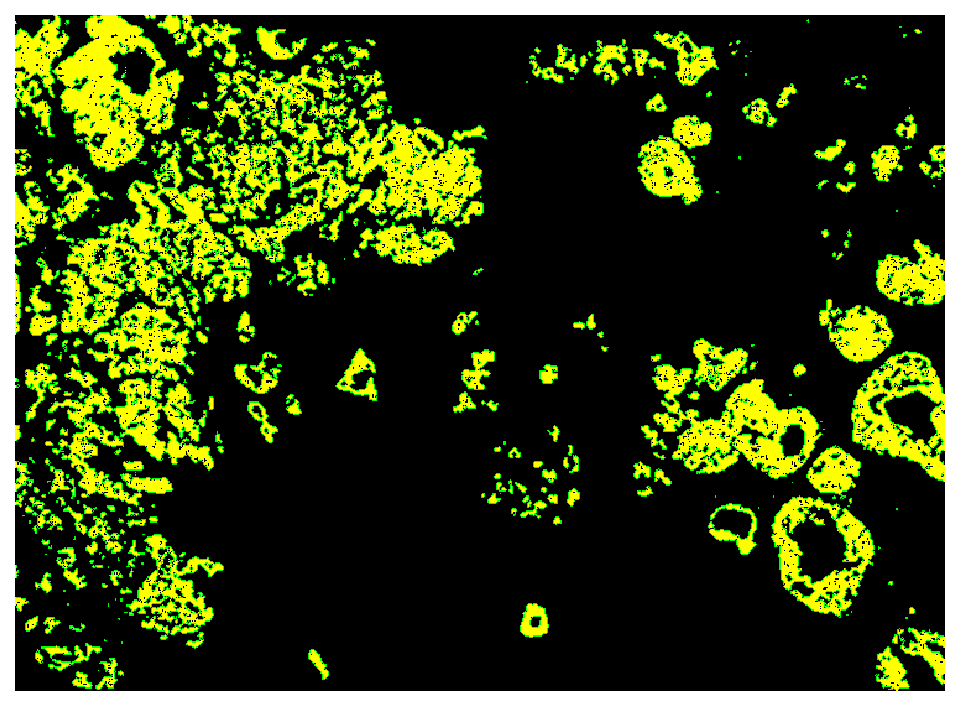

In [20]:
# Figure 2B
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.imshow(cv2.cvtColor(grid.uns["marker_median_delineation"], cv2.COLOR_BGR2RGB),
          interpolation="nearest")
ax.axis("off")
plt.show()

#plt.savefig("Figure_2B.png", dpi=300)

In [21]:
import plotly.express as px
import plotly.io as pio
import cv2
import numpy as np

# Convert BGR (OpenCV) image to RGB for Plotly display
img = cv2.cvtColor(grid.uns["marker_median_delineation"], cv2.COLOR_BGR2RGB)

scale = 10  # spatial scaling factor

fig = px.imshow(img)

h, w = img.shape[:2]

# ---- Scale axis tick labels by a factor of 10 ----
step = 200
fig.update_xaxes(
    tickmode="array",
    tickvals=list(range(0, w, step)),
    ticktext=[str(v * scale) for v in range(0, w, step)]
)
fig.update_yaxes(
    tickmode="array",
    tickvals=list(range(0, h, step)),
    ticktext=[str(v * scale) for v in range(0, h, step)]
)

# ---- Create a full-resolution coordinate grid for hover display ----
# xx: scaled x-coordinates for each pixel (shape: h × w)
# yy: scaled y-coordinates for each pixel (shape: h × w)
xx = (np.arange(w)[None, :] * scale).repeat(h, axis=0)
yy = (np.arange(h)[:, None] * scale).repeat(w, axis=1)

# Stack into (h, w, 2) so hover can access scaled x and y
custom = np.dstack([xx, yy])

# ---- Override hover text to show scaled spatial coordinates ----
fig.update_traces(
    customdata=custom,
    hovertemplate="x: %{customdata[0]}<br>y: %{customdata[1]}<extra></extra>"
)

fig.update_layout(
    title="Figure 2B",
    xaxis_title="x",
    yaxis_title="y",
    height=700
)

# Use the notebook-connected renderer for interactive display
pio.renderers.default = "notebook_connected"

fig.show()

# ↓↓ Zooming and cropping are supported interactively ↓↓

In [22]:
import plotly.express as px
import cv2

img = cv2.cvtColor(
    grid.uns["marker_median_delineation"],
    cv2.COLOR_BGR2RGB
)

fig = px.imshow(img)

fig.update_layout(
    title="Figure 2B",
    xaxis_title="x",
    yaxis_title="y",
    height=700
)

fig.show()


In [23]:
# annotation each section to obs object
df_shotest = getattr(grid, "shortest")
df_grid = grid.to_df()

# extract grid info
df_grid = pd.merge(
    pd.DataFrame(index=["grid_" + str(i+1) for i in range(N_ROW * N_COL)]),
    df_grid, right_index=True, left_index=True, how="left"
).fillna(np.nan)

# extract section info
df_region = pd.DataFrame(
    np.array(df_shotest["region"]).reshape(N_ROW, N_COL).T.reshape(N_ROW * N_COL),
    index=["grid_" + str(i+1) for i in range(N_ROW * N_COL)], columns=["region"]
)

# marge
df_grid_region = pd.merge(
    df_grid, df_region,
    right_index=True, left_index=True, how="left"
)
df_grid_region = df_grid_region.dropna()

# add to obs
grid.obs = pd.merge(
    grid.obs, df_grid_region[["region"]],
    right_index=True, left_index=True, how="left"
)

# shaping
grid.obs["region_10"] = [str(i*10) for i in grid.obs["region"]]
grid.obs["region_10"] = ["("+str(int(float(i.split(", ")[0][1:])))+", "+str(int(float(i.split(", ")[-1][:-1])))+"]" if i != "nan" else np.nan for i in grid.obs["region_10"]]
# exclude because of small number
grid.obs["region_10"] = grid.obs["region_10"].replace(
    {"(-150, -120]": np.nan}
)

In [24]:
from scomv.gene_pipeline import SCOMVPipeline

gene_pipe = SCOMVPipeline(adata=adata, grid=grid, bin_size=10)


In [25]:
dfs = []
pcoa_results = []

roi_list = [
    (4800, 5900, 950, 1900),
    (6920, 7570, 1910, 2390),
    (5300, 6400, 3050, 3900),
    (6050, 7050, 3910, 5100),
    (3900, 4500, 4600, 5200),
    (2400, 3400, 2400, 3800),
    (2700, 4000, 750, 1690),
    (1000, 2100, 1700, 2500),
    (400, 1500, 3600, 4200),
    (900, 1700, 4200, 5300),
    
]
for roi in roi_list:
    gene_out = gene_pipe.run(roi=roi)
    dfs.append(gene_out["dist_df"])
    pcoa_results.append(gene_out["pcoa_res"])
    
    

  0%|          | 0/100 [00:00<?, ?/s]

/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning:

1 variables were constant, will return nan for these.



  0%|          | 0/100 [00:00<?, ?/s]

/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning:

1 variables were constant, will return nan for these.



  0%|          | 0/100 [00:00<?, ?/s]

...

/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


  0%|          | 0/100 [00:00<?, ?/s]

/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


  0%|          | 0/100 [00:00<?, ?/s]

/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [17]:
common_genes = set.intersection(*[set(df.index) for df in dfs])

print(f"the number of common genes: {len(common_genes)}")

for i in range(len(dfs)):
    dfs[i] = dfs[i].loc[sorted(common_genes), sorted(common_genes)]

the number of common genes: 157


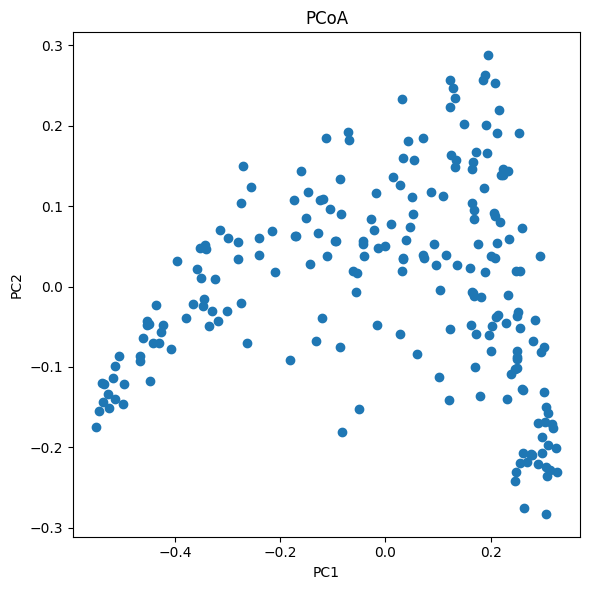

In [26]:
# 座標取得（サンプルのPC座標）
coords = pcoa_results[5].samples   # DataFrame

# PC1, PC2
x = coords.iloc[:, 0]
y = coords.iloc[:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(x, y)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCoA")
#plt.axhline(0, linewidth=0.5)
#plt.axvline(0, linewidth=0.5)
plt.tight_layout()
plt.show()


In [27]:
import plotly.express as px

coords = pcoa_results[5].samples.copy()

# 行名（細胞名）を列にする
coords["cell_name"] = coords.index

fig = px.scatter(
    coords,
    x=coords.columns[0],   # PC1
    y=coords.columns[1],   # PC2
    hover_name="cell_name"
)

fig.update_layout(
    title="PCoA",
    xaxis_title="PC1",
    yaxis_title="PC2",
    height=800
)

fig.show()


In [27]:
pcoa_results[5].samples 

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC210,PC211,PC212,PC213,PC214,PC215,PC216,PC217,PC218,PC219
ACTA2,-0.151801,0.085364,-0.150295,-0.138119,0.013741,0.029708,-0.002419,-0.014524,-0.029032,-0.006472,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG2,-0.054990,0.016347,-0.150434,0.016256,-0.033946,-0.020138,0.012389,0.018783,-0.031833,-0.025580,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADAM9,-0.070972,0.192501,-0.075939,-0.001446,-0.035479,-0.001239,-0.017906,0.050946,0.013357,-0.002156,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADGRE5,0.238680,-0.108531,-0.064706,0.010353,-0.032158,0.009807,0.007555,-0.018914,-0.002910,0.036612,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADH1B,0.131419,0.148991,0.388114,0.027863,-0.124053,0.023687,-0.019984,0.003152,-0.025043,-0.076759,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VWF,0.181532,-0.012944,0.106835,-0.213366,-0.057542,-0.125779,0.182977,0.048310,-0.060514,0.061967,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WARS,0.122919,-0.053082,-0.158708,-0.041235,0.035483,0.012526,-0.014213,-0.027590,-0.015024,0.014509,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ZEB1,0.109488,0.113113,-0.104328,-0.116692,0.028390,0.084712,0.007514,-0.036787,-0.018227,0.025053,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ZEB2,0.206194,0.091381,-0.081663,-0.012826,0.059374,0.022708,0.049535,-0.016549,-0.015629,0.013181,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
import numpy as np
import scipy.optimize as opt
import scipy.sparse as sps
import numpy.linalg as nla
import scipy.linalg as sla
import time

## https://github.com/kushalkolar/symmetric-nmf/blob/main/example.py

# vendored from https://github.com/kimjingu/nonnegfac-python


def nnlsm_blockpivot(A, B, is_input_prod=False, init=None):
    """ Nonnegativity-constrained least squares with block principal pivoting method and column grouping

    Solves min ||AX-B||_2^2 s.t. X >= 0 element-wise.

    J. Kim and H. Park, Fast nonnegative matrix factorization: An active-set-like method and comparisons,
    SIAM Journal on Scientific Computing,
    vol. 33, no. 6, pp. 3261-3281, 2011.

    Parameters
    ----------
    A : numpy.array, shape (m,n)
    B : numpy.array or scipy.sparse matrix, shape (m,k)

    Optional Parameters
    -------------------
    is_input_prod : True/False. -  If True, the A and B arguments are interpreted as
            AtA and AtB, respectively. Default is False.
    init: numpy.array, shape (n,k). - If provided, init is used as an initial value for the algorithm.
            Default is None.

    Returns
    -------
    X, (success, Y, num_cholesky, num_eq, num_backup)
    X : numpy.array, shape (n,k) - solution
    success : True/False - True if the solution is found. False if the algorithm did not terminate
            due to numerical errors.
    Y : numpy.array, shape (n,k) - Y = A.T * A * X - A.T * B
    num_cholesky : int - the number of Cholesky factorizations needed
    num_eq : int - the number of linear systems of equations needed to be solved
    num_backup: int - the number of appearances of the back-up rule. See SISC paper for details.
    """
    if is_input_prod:
        AtA = A
        AtB = B
    else:
        AtA = A.T.dot(A)
        if sps.issparse(B):
            AtB = B.T.dot(A)
            AtB = AtB.T
        else:
            AtB = A.T.dot(B)

    (n, k) = AtB.shape
    MAX_ITER = n * 5

    if init is not  None:
        PassSet = init > 0
        X, num_cholesky, num_eq = normal_eq_comb(AtA, AtB, PassSet)
        Y = AtA.dot(X) - AtB
    else:
        X = np.zeros([n, k])
        Y = -AtB
        PassSet = np.zeros([n, k], dtype=bool)
        num_cholesky = 0
        num_eq = 0

    p_bar = 3
    p_vec = np.zeros([k])
    p_vec[:] = p_bar
    ninf_vec = np.zeros([k])
    ninf_vec[:] = n + 1
    not_opt_set = np.logical_and(Y < 0, ~PassSet)
    infea_set = np.logical_and(X < 0, PassSet)

    not_good = np.sum(not_opt_set, axis=0) + np.sum(infea_set, axis=0)
    not_opt_colset = not_good > 0
    not_opt_cols = not_opt_colset.nonzero()[0]

    big_iter = 0
    num_backup = 0
    success = True
    while not_opt_cols.size > 0:
        big_iter += 1
        if MAX_ITER > 0 and big_iter > MAX_ITER:
            success = False
            break

        cols_set1 = np.logical_and(not_opt_colset, not_good < ninf_vec)
        temp1 = np.logical_and(not_opt_colset, not_good >= ninf_vec)
        temp2 = p_vec >= 1
        cols_set2 = np.logical_and(temp1, temp2)
        cols_set3 = np.logical_and(temp1, ~temp2)

        cols1 = cols_set1.nonzero()[0]
        cols2 = cols_set2.nonzero()[0]
        cols3 = cols_set3.nonzero()[0]

        if cols1.size > 0:
            p_vec[cols1] = p_bar
            ninf_vec[cols1] = not_good[cols1]
            true_set = np.logical_and(not_opt_set, np.tile(cols_set1, (n, 1)))
            false_set = np.logical_and(infea_set, np.tile(cols_set1, (n, 1)))
            PassSet[true_set] = True
            PassSet[false_set] = False
        if cols2.size > 0:
            p_vec[cols2] = p_vec[cols2] - 1
            temp_tile = np.tile(cols_set2, (n, 1))
            true_set = np.logical_and(not_opt_set, temp_tile)
            false_set = np.logical_and(infea_set, temp_tile)
            PassSet[true_set] = True
            PassSet[false_set] = False
        if cols3.size > 0:
            for col in cols3:
                candi_set = np.logical_or(
                    not_opt_set[:, col], infea_set[:, col])
                to_change = np.max(candi_set.nonzero()[0])
                PassSet[to_change, col] = ~PassSet[to_change, col]
                num_backup += 1

        (X[:, not_opt_cols], temp_cholesky, temp_eq) = normal_eq_comb(
            AtA, AtB[:, not_opt_cols], PassSet[:, not_opt_cols])
        num_cholesky += temp_cholesky
        num_eq += temp_eq
        X[abs(X) < 1e-12] = 0
        Y[:, not_opt_cols] = AtA.dot(X[:, not_opt_cols]) - AtB[:, not_opt_cols]
        Y[abs(Y) < 1e-12] = 0

        not_opt_mask = np.tile(not_opt_colset, (n, 1))
        not_opt_set = np.logical_and(
            np.logical_and(not_opt_mask, Y < 0), ~PassSet)
        infea_set = np.logical_and(
            np.logical_and(not_opt_mask, X < 0), PassSet)
        not_good = np.sum(not_opt_set, axis=0) + np.sum(infea_set, axis=0)
        not_opt_colset = not_good > 0
        not_opt_cols = not_opt_colset.nonzero()[0]

    return X, (success, Y, num_cholesky, num_eq, num_backup)


def nnlsm_activeset(A, B, overwrite=False, is_input_prod=False, init=None):
    """ Nonnegativity-constrained least squares with active-set method and column grouping

    Solves min ||AX-B||_2^2 s.t. X >= 0 element-wise.

    Algorithm of this routine is close to the one presented in the following paper but
    is different in organising inner- and outer-loops:
    M. H. Van Benthem and M. R. Keenan, J. Chemometrics 2004; 18: 441-450

    Parameters
    ----------
    A : numpy.array, shape (m,n)
    B : numpy.array or scipy.sparse matrix, shape (m,k)

    Optional Parameters
    -------------------
    is_input_prod : True/False. -  If True, the A and B arguments are interpreted as
            AtA and AtB, respectively. Default is False.
    init: numpy.array, shape (n,k). - If provided, init is used as an initial value for the algorithm.
            Default is None.

    Returns
    -------
    X, (success, Y, num_cholesky, num_eq, num_backup)
    X : numpy.array, shape (n,k) - solution
    success : True/False - True if the solution is found. False if the algorithm did not terminate
            due to numerical errors.
    Y : numpy.array, shape (n,k) - Y = A.T * A * X - A.T * B
    num_cholesky : int - the number of Cholesky factorizations needed
    num_eq : int - the number of linear systems of equations needed to be solved
    """
    if is_input_prod:
        AtA = A
        AtB = B
    else:
        AtA = A.T.dot(A)
        if sps.issparse(B):
            AtB = B.T.dot(A)
            AtB = AtB.T
        else:
            AtB = A.T.dot(B)

    (n, k) = AtB.shape
    MAX_ITER = n * 5
    num_cholesky = 0
    num_eq = 0
    not_opt_set = np.ones([k], dtype=bool)

    if overwrite:
        X, num_cholesky, num_eq = normal_eq_comb(AtA, AtB)
        PassSet = X > 0
        not_opt_set = np.any(X < 0, axis=0)
    elif init is not None:
        X = init
        X[X < 0] = 0
        PassSet = X > 0
    else:
        X = np.zeros([n, k])
        PassSet = np.zeros([n, k], dtype=bool)

    Y = np.zeros([n, k])
    opt_cols = (~not_opt_set).nonzero()[0]
    not_opt_cols = not_opt_set.nonzero()[0]

    Y[:, opt_cols] = AtA.dot(X[:, opt_cols]) - AtB[:, opt_cols]

    big_iter = 0
    success = True
    while not_opt_cols.size > 0:
        big_iter += 1
        if MAX_ITER > 0 and big_iter > MAX_ITER:
            success = False
            break

        (Z, temp_cholesky, temp_eq) = normal_eq_comb(
            AtA, AtB[:, not_opt_cols], PassSet[:, not_opt_cols])
        num_cholesky += temp_cholesky
        num_eq += temp_eq

        Z[abs(Z) < 1e-12] = 0

        infea_subset = Z < 0
        temp = np.any(infea_subset, axis=0)
        infea_subcols = temp.nonzero()[0]
        fea_subcols = (~temp).nonzero()[0]

        if infea_subcols.size > 0:
            infea_cols = not_opt_cols[infea_subcols]

            (ix0, ix1_subsub) = infea_subset[:, infea_subcols].nonzero()
            ix1_sub = infea_subcols[ix1_subsub]
            ix1 = not_opt_cols[ix1_sub]

            X_infea = X[(ix0, ix1)]

            alpha = np.zeros([n, len(infea_subcols)])
            alpha[:] = np.inf
            alpha[(ix0, ix1_subsub)] = X_infea / (X_infea - Z[(ix0, ix1_sub)])
            min_ix = np.argmin(alpha, axis=0)
            min_vals = alpha[(min_ix, range(0, alpha.shape[1]))]

            X[:, infea_cols] = X[:, infea_cols] + \
                (Z[:, infea_subcols] - X[:, infea_cols]) * min_vals
            X[(min_ix, infea_cols)] = 0
            PassSet[(min_ix, infea_cols)] = False

        elif fea_subcols.size > 0:
            fea_cols = not_opt_cols[fea_subcols]

            X[:, fea_cols] = Z[:, fea_subcols]
            Y[:, fea_cols] = AtA.dot(X[:, fea_cols]) - AtB[:, fea_cols]

            Y[abs(Y) < 1e-12] = 0

            not_opt_subset = np.logical_and(
                Y[:, fea_cols] < 0, ~PassSet[:, fea_cols])
            new_opt_cols = fea_cols[np.all(~not_opt_subset, axis=0)]
            update_cols = fea_cols[np.any(not_opt_subset, axis=0)]

            if update_cols.size > 0:
                val = Y[:, update_cols] * ~PassSet[:, update_cols]
                min_ix = np.argmin(val, axis=0)
                PassSet[(min_ix, update_cols)] = True

            not_opt_set[new_opt_cols] = False
            not_opt_cols = not_opt_set.nonzero()[0]

    return X, (success, Y, num_cholesky, num_eq)


def normal_eq_comb(AtA, AtB, PassSet=None):
    """ Solve many systems of linear equations using combinatorial grouping.

    M. H. Van Benthem and M. R. Keenan, J. Chemometrics 2004; 18: 441-450

    Parameters
    ----------
    AtA : numpy.array, shape (n,n)
    AtB : numpy.array, shape (n,k)

    Returns
    -------
    (Z,num_cholesky,num_eq)
    Z : numpy.array, shape (n,k) - solution
    num_cholesky : int - the number of unique cholesky decompositions done
    num_eq: int - the number of systems of linear equations solved
    """
    num_cholesky = 0
    num_eq = 0
    if AtB.size == 0:
        Z = np.zeros([])
    elif (PassSet is None) or np.all(PassSet):
        Z = nla.solve(AtA, AtB)
        num_cholesky = 1
        num_eq = AtB.shape[1]
    else:
        Z = np.zeros(AtB.shape)
        if PassSet.shape[1] == 1:
            if np.any(PassSet):
                cols = PassSet.nonzero()[0]
                Z[cols] = nla.solve(AtA[np.ix_(cols, cols)], AtB[cols])
                num_cholesky = 1
                num_eq = 1
        else:
            #
            # Both _column_group_loop() and _column_group_recursive() work well.
            # Based on preliminary testing,
            # _column_group_loop() is slightly faster for tiny k(<10), but
            # _column_group_recursive() is faster for large k's.
            #
            grps = _column_group_recursive(PassSet)
            for gr in grps:
                cols = PassSet[:, gr[0]].nonzero()[0]
                if cols.size > 0:
                    ix1 = np.ix_(cols, gr)
                    ix2 = np.ix_(cols, cols)
                    #
                    # scipy.linalg.cho_solve can be used instead of numpy.linalg.solve.
                    # For small n(<200), numpy.linalg.solve appears faster, whereas
                    # for large n(>500), scipy.linalg.cho_solve appears faster.
                    # Usage example of scipy.linalg.cho_solve:
                    # Z[ix1] = sla.cho_solve(sla.cho_factor(AtA[ix2]),AtB[ix1])
                    #
                    Z[ix1] = nla.solve(AtA[ix2], AtB[ix1])
                    num_cholesky += 1
                    num_eq += len(gr)
                    num_eq += len(gr)
    return Z, num_cholesky, num_eq


def _column_group_loop(B):
    """ Given a binary matrix, find groups of the same columns
        with a looping strategy

    Parameters
    ----------
    B : numpy.array, True/False in each element

    Returns
    -------
    A list of arrays - each array contain indices of columns that are the same.
    """
    initial = [np.arange(0, B.shape[1])]
    before = initial
    after = []
    for i in range(0, B.shape[0]):
        all_ones = True
        vec = B[i]
        for cols in before:
            if len(cols) == 1:
                after.append(cols)
            else:
                all_ones = False
                subvec = vec[cols]
                trues = subvec.nonzero()[0]
                falses = (~subvec).nonzero()[0]
                if trues.size > 0:
                    after.append(cols[trues])
                if falses.size > 0:
                    after.append(cols[falses])
        before = after
        after = []
        if all_ones:
            break
    return before


def _column_group_recursive(B):
    """ Given a binary matrix, find groups of the same columns
        with a recursive strategy

    Parameters
    ----------
    B : numpy.array, True/False in each element

    Returns
    -------
    A list of arrays - each array contain indices of columns that are the same.
    """
    initial = np.arange(0, B.shape[1])
    return [a for a in column_group_sub(B, 0, initial) if len(a) > 0]


def column_group_sub(B, i, cols):
    vec = B[i][cols]
    if len(cols) <= 1:
        return [cols]
    if i == (B.shape[0] - 1):
        col_trues = cols[vec.nonzero()[0]]
        col_falses = cols[(~vec).nonzero()[0]]
        return [col_trues, col_falses]
    else:
        col_trues = cols[vec.nonzero()[0]]
        col_falses = cols[(~vec).nonzero()[0]]
        after = column_group_sub(B, i + 1, col_trues)
        after.extend(column_group_sub(B, i + 1, col_falses))
    return after


def _test_column_grouping(m=10, n=5000, num_repeat=5, verbose=False):
    print ('\nTesting column_grouping ...\n')
    A = np.array([[True, False, False, False, False],
                  [True, True, False, True, True]])
    grps1 = _column_group_loop(A)
    grps2 = _column_group_recursive(A)
    grps3 = [np.array([0]),
             np.array([1, 3, 4]),
             np.array([2])]
    print ('OK' if all([np.array_equal(a, b) for (a, b) in zip(grps1, grps2)]) else 'Fail')
    print ('OK' if all([np.array_equal(a, b) for (a, b) in zip(grps1, grps3)]) else 'Fail')

    for i in iter(range(0, num_repeat)):
        A = np.random.rand(m, n)
        B = A > 0.5
        start = time.time()
        grps1 = _column_group_loop(B)
        elapsed_loop = time.time() - start
        start = time.time()
        grps2 = _column_group_recursive(B)
        elapsed_recursive = time.time() - start
        if verbose:
            print ('Loop     :', elapsed_loop)
            print ('Recursive:', elapsed_recursive)
        print ('OK' if all([np.array_equal(a, b) for (a, b) in zip(grps1, grps2)]) else 'Fail')
    # sorted_idx = np.concatenate(grps)
    # print B
    # print sorted_idx
    # print B[:,sorted_idx]
    return


def _test_normal_eq_comb(m=10, k=3, num_repeat=5):
    print ('\nTesting normal_eq_comb() ...\n')
    for i in iter(range(0, num_repeat)):
        A = np.random.rand(2 * m, m)
        X = np.random.rand(m, k)
        C = (np.random.rand(m, k) > 0.5)
        X[~C] = 0
        B = A.dot(X)
        B = A.T.dot(B)
        A = A.T.dot(A)
        Sol, a, b = normal_eq_comb(A, B, C)
        print ('OK' if np.allclose(X, Sol) else 'Fail')
    return


def _test_nnlsm():
    print ('\nTesting nnls routines ...\n')
    m = 100
    n = 10
    k = 200
    rep = 5

    for r in iter(range(0, rep)):
        A = np.random.rand(m, n)
        X_org = np.random.rand(n, k)
        X_org[np.random.rand(n, k) < 0.5] = 0
        B = A.dot(X_org)
        # B = np.random.rand(m,k)
        # A = np.random.rand(m,n/2)
        # A = np.concatenate((A,A),axis=1)
        # A = A + np.random.rand(m,n)*0.01
        # B = np.random.rand(m,k)

        import time
        start = time.time()
        C1, info = nnlsm_blockpivot(A, B)
        elapsed2 = time.time() - start
        rel_norm2 = nla.norm(C1 - X_org) / nla.norm(X_org)
        print ('nnlsm_blockpivot:    ', 'OK  ' if info[0] else 'Fail',\
            'elapsed:{0:.4f} error:{1:.4e}'.format(elapsed2, rel_norm2))

        start = time.time()
        C2, info = nnlsm_activeset(A, B)
        num_backup = 0
        elapsed1 = time.time() - start
        rel_norm1 = nla.norm(C2 - X_org) / nla.norm(X_org)
        print ('nnlsm_activeset:     ', 'OK  ' if info[0] else 'Fail',\
            'elapsed:{0:.4f} error:{1:.4e}'.format(elapsed1, rel_norm1))

        start = time.time()
        C3 = np.zeros([n, k])
        for i in iter(range(0, k)):
            res = opt.nnls(A, B[:, i])
            C3[:, i] = res[0]
        elapsed3 = time.time() - start
        rel_norm3 = nla.norm(C3 - X_org) / nla.norm(X_org)
        print ('scipy.optimize.nnls: ', 'OK  ',\
            'elapsed:{0:.4f} error:{1:.4e}'.format(elapsed3, rel_norm3))

        if num_backup > 0:
            break
        if rel_norm1 > 10e-5 or rel_norm2 > 10e-5 or rel_norm3 > 10e-5:
            break
        print ('')

if __name__ == '__main__':
    _test_column_grouping()
    _test_normal_eq_comb()
    _test_nnlsm()


Testing column_grouping ...

OK
OK
OK
OK
OK
OK
OK

Testing normal_eq_comb() ...

OK
OK
OK
OK
OK

Testing nnls routines ...

nnlsm_blockpivot:     OK   elapsed:0.0004 error:5.7203e-15
nnlsm_activeset:      OK   elapsed:0.0120 error:5.2572e-15
scipy.optimize.nnls:  OK   elapsed:0.0044 error:8.2453e-16

nnlsm_blockpivot:     OK   elapsed:0.0002 error:5.0313e-15
nnlsm_activeset:      OK   elapsed:0.0101 error:4.7144e-15
scipy.optimize.nnls:  OK   elapsed:0.0022 error:8.9167e-16

nnlsm_blockpivot:     OK   elapsed:0.0001 error:5.4765e-15
nnlsm_activeset:      OK   elapsed:0.0045 error:4.7618e-15
scipy.optimize.nnls:  OK   elapsed:0.0020 error:8.8592e-16

nnlsm_blockpivot:     OK   elapsed:0.0001 error:4.8064e-15
nnlsm_activeset:      OK   elapsed:0.0099 error:4.3643e-15
scipy.optimize.nnls:  OK   elapsed:0.0042 error:9.1285e-16

nnlsm_blockpivot:     OK   elapsed:0.0001 error:5.0548e-15
nnlsm_activeset:      OK   elapsed:0.0041 error:4.5838e-15
scipy.optimize.nnls:  OK   elapsed:0.0020 err

  0%|                                                                               | 10/10000 [00:00<00:18, 541.86it/s]
/var/folders/h5/02yhm93d3kn1__fczqjdr9cw0000gp/T/ipykernel_81124/2218498750.py:121: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



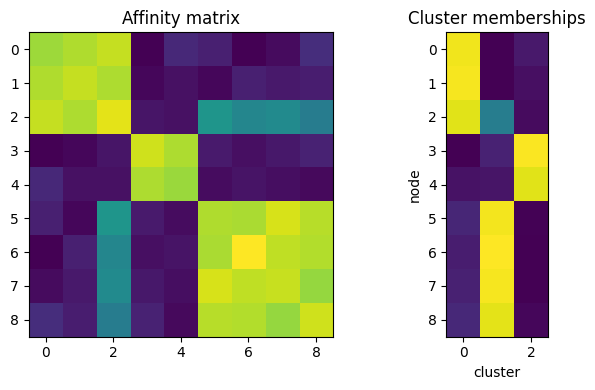

In [29]:
import numpy as np
from tqdm import tqdm

#from .nnls import nnlsm_blockpivot


class SymNMF:
    """Symmetric NMF using ANLS"""
    def __init__(
            self,
            k: int,
            maxiter: int = 10_000,
            tol: float = 10e-3,
            alpha: float = None,
    ):

        self.alpha_ = alpha
        self.maxiter_ = maxiter
        self.tol_ = tol
        self.k_ = k

    def fit(self, A: np.ndarray, H_init: np.ndarray = None):
        self.A = A

        if H_init is None:
            H_init = 2 * np.sqrt(np.mean(np.mean(A) / self.k_)) * np.random.rand(self.A.shape[0], self.k_)
        else:
            if H_init.shape[0] != A.shape[0]:
                raise ValueError(f"H_init.shape[0] != A.shape[0], {H_init.shape[0]} != {A.shape[0]}")

        self.H_init_ = H_init

        if self.alpha_ is None:
            self.alpha_ = np.max(self.A) **2

        self.H = self.H_init_.copy()

        self.W = self.H
        I_k = self.alpha_ * np.eye(self.k_)

        self.left = self.H.conj().T @ self.H
        self.right = self.A @ self.H

        for i in tqdm(range(self.maxiter_)):
            self.W = nnlsm_blockpivot(
                self.left + I_k,
                (self.right + self.alpha_ * self.H).conj().T,
                True,
                self.W.conj().T
            )[0].T

            self.left = self.W.conj().T @ self.W
            self.right = self.A @ self.W

            self.H = nnlsm_blockpivot(
                self.left + I_k,
                (self.right + self.alpha_ * self.W).conj().T,
                True,
                self.H.conj().T
            )[0].T
            # tempW = W.sum(axis=1)
            # tempH = H.sum(axis=1)

            temp = self.alpha_ * (self.H - self.W)

            gradH = self.H @ self.left - self.right + temp
            self.left = self.H.conj().T @ self.H
            self.right = self.A @ self.H

            gradW = self.W @ self.left - self.right - temp

            W_norm = np.linalg.norm(gradW[(gradW <= 0) | (self.W > 0)])
            H_norm = np.linalg.norm(gradH[(gradH <= 0) | (self.H > 0)])

            if i == 0:
                initgrad = np.sqrt(W_norm ** 2 + H_norm ** 2)
            else:
                projnorm = np.sqrt(W_norm ** 2 + H_norm ** 2)
                if projnorm < self.tol_ * initgrad:
                    break

#import numpy as np
#from symmnmf import SymNMF
#from matplotlib import pyplot as plt


np.random.seed(297)

A = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 0, 0.5, 0.5, 0.5, 0.5], # partial membership
    [0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0.5, 0, 0, 1, 1, 1, 1],
    [0, 0, 0.5, 0, 0, 1, 1, 1, 1],
    [0, 0, 0.5, 0, 0, 1, 1, 1, 1],
    [0, 0, 0.5, 0, 0, 1, 1, 1, 1],
])

# simulate some noise
sigma = np.abs(np.random.normal(scale=0.1, size=A.size)).reshape(A.shape)
# make symmetric and add noise
noise = (sigma + sigma.T) / 2
A += noise

snmf = SymNMF(k=3)
snmf.fit(A)

fig, axs = plt.subplots(1, 2, figsize=(7, 4))

axs[0].imshow(A)
axs[0].set_title("Affinity matrix")

axs[1].imshow(snmf.H)
axs[1].set_title("Cluster memberships")
axs[1].set_xlabel("cluster")
axs[1].set_ylabel("node")

fig.tight_layout()
fig.show()


In [30]:
from sklearn.decomposition import NMF

n_components = 1  # 分解する因子数（適宜変更してください）

W_results = {}
H_results = {}


np.random.seed(123)


for i in range(len(dfs)):

    df = dfs[i]
    A = df.to_numpy()
    # simulate some noise
    sigma = np.abs(np.random.normal(scale=0.1, size=A.size)).reshape(A.shape)
    # make symmetric and add noise
    noise = (sigma + sigma.T) / 2
    A += noise
    
    snmf = SymNMF(k=n_components)
    snmf.fit(A)
    
    H_results[roi_list[i]] = snmf.H
    


  1%|▋                                                                             | 82/10000 [00:00<00:01, 6119.80it/s]


In [23]:
#H_results

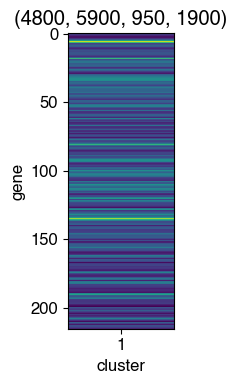

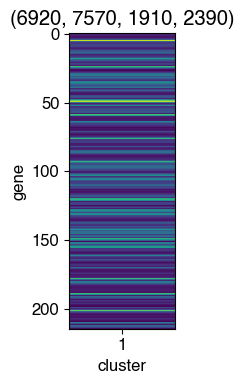

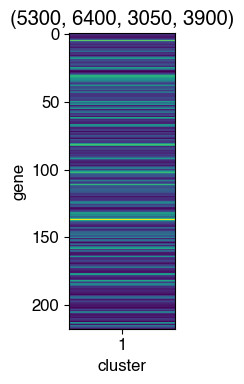

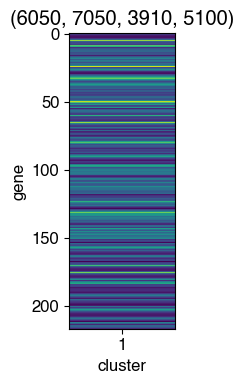

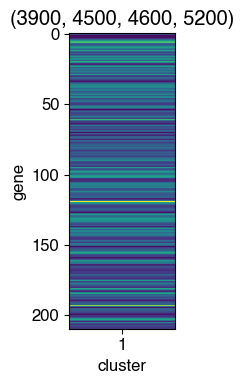

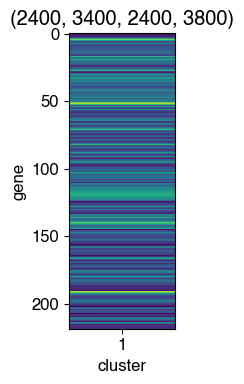

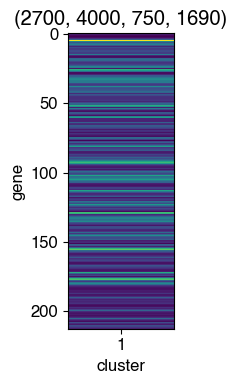

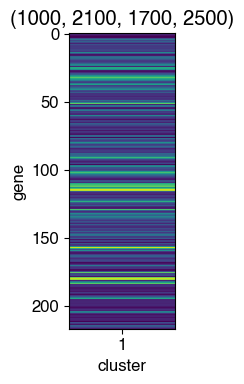

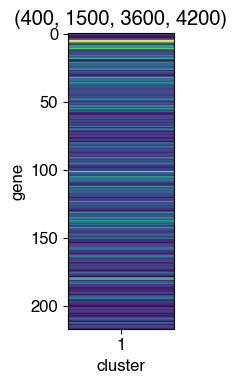

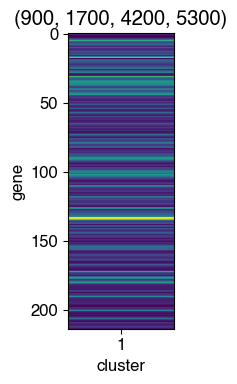

In [37]:
import matplotlib.pyplot as plt

for key, H in H_results.items():
    plt.figure(figsize=(2, 4))
    plt.imshow(H, aspect='auto')
    plt.title(f"{key}")
    plt.xlabel("cluster")

    num_clusters = H.shape[1]
    plt.xticks(ticks=range(num_clusters), labels=[str(i+1) for i in range(num_clusters)])

    plt.ylabel("gene")
    plt.tight_layout()
    plt.savefig(f"nmf_{key}_n_1.png")
    #plt.show()


In [32]:
feature_matrix = []
keys = []

for key, H in H_results.items():
    mean_vec = H.mean(axis=1)
    feature_matrix.append(mean_vec)
    keys.append(key)

feature_matrix = np.array(feature_matrix)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [33]:
from sklearn.cluster import KMeans

n_clusters = 3  # define the number of cluster
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
clusters = kmeans.fit_predict(feature_matrix)

print("the result of clustering:", clusters)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram

annotation_dist = {}
annotation_dist["4800<x<5900, 950<y<1900"]= "1 (DCIS)"
annotation_dist["6920<x<7570, 1910<y<2390"]= "2 (DCIS)"
annotation_dist["5300<x<6400, 3050<y<3900"]= "3 (DCIS)"
annotation_dist["6050<x<7050, 3910<y<5100"]= "4 (DCIS)"
annotation_dist["3900<x<4500, 4600<y<5200"]= "5 (DCIS)"
annotation_dist["2400<x<3400, 2400<y<3800"]= "6 (DCIS)"

annotation_dist["2700<x<4000, 750<y<1690"]= "7 (IDC)"
annotation_dist["1000<x<2100, 1700<y<2500"]= "8 (IDC)"
annotation_dist["400<x<1500, 3600<y<4200"]= "9 (IDC)"
annotation_dist["900<x<1700, 4200<y<5300"]= "10 (IDC)"


# ======== Prepare data for clustering ========
feature_matrix = []
keys = []

for key, H in H_results.items():
    # H: shape = (n_components, n_samples)
    mean_vec = H.mean(axis=1)
    feature_matrix.append(mean_vec)
    keys.append(key)

feature_matrix = np.array(feature_matrix)

# ======== KMeans clustering ========
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
clusters = kmeans.fit_predict(feature_matrix)
print("Clustering results (groups of 10 datasets):", clusters)

# ======== Hierarchical clustering ========
#labels = [f"ROI{annotation_dist[key]}" for key in keys]
labels = [f"ROI{annotation_dist[f'{x1}<x<{x2}, {y1}<y<{y2}']}" for (x1, x2, y1, y2) in keys]
Z = linkage(feature_matrix, method="average")

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [35]:
#annotation_dist

NameError: name 'Z' is not defined

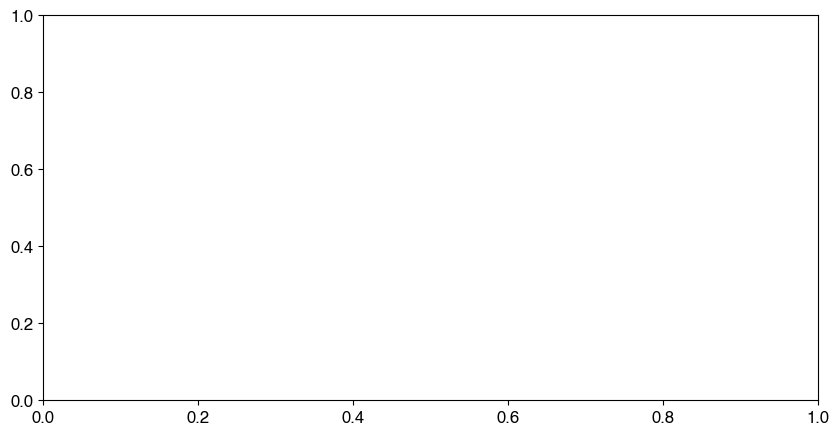

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from adjustText import adjust_text

plt.rcParams.update({
    "font.size": 12,
    "font.family": "Helvetica",
})

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(
    Z,
    labels=labels,
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=None,
    above_threshold_color='black',
    ax=ax
)

ax.set_ylabel("Distance", fontsize=12)
ax.set_xlabel("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig("dendrogram_n_20.png", dpi=600, bbox_inches='tight')
plt.show()

# ======== PCA で 2次元化 ========
pca = PCA(n_components=2, random_state=0)
feature_matrix_2d = pca.fit_transform(feature_matrix)

# ======== IDC / DCIS 判定 & 色マップ ========
color_map = {"IDC": "red", "DCIS": "blue"}

plt.figure(figsize=(8, 6))
texts = []
prev_group = None

for i, key in enumerate(keys):
    x, y = feature_matrix_2d[i]

    # ROI番号抽出（改行より前）
    roi_number = annotation_dist[key].split('\n')[0]
    label = f"ROI{roi_number}"

    group = "IDC" if "IDC" in annotation_dist[key] else "DCIS"
    color = color_map[group]

    plt.scatter(x, y, s=100, c=color, label=group if i == 0 or group != prev_group else "")
    texts.append(plt.text(x, y, label, fontsize=14))
    prev_group = group

# テキスト位置調整
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

plt.title("PCA projection (IDC vs DCIS)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# 重複しない凡例
handles, labels_ = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
plt.legend(by_label.values(), by_label.keys(), loc="best")

plt.tight_layout()
#plt.savefig("pca_idc_dcis_adjusted_n_20.png", dpi=600)
plt.show()


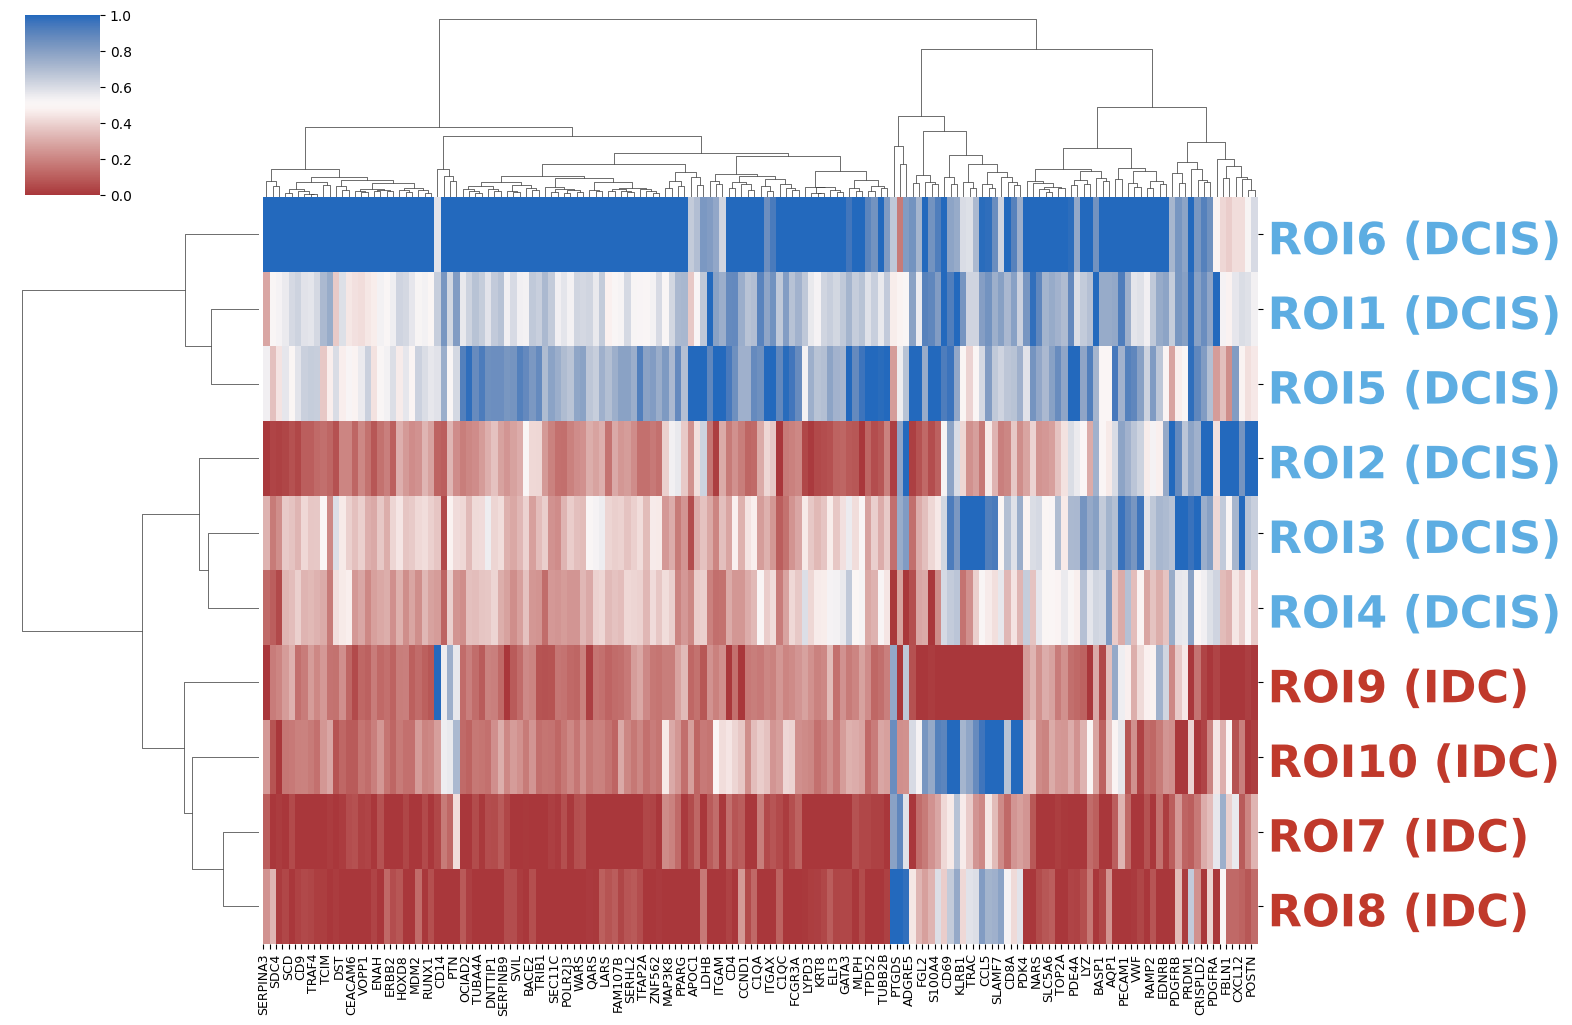

In [16]:
import matplotlib.patheffects as pe

df_features = pd.DataFrame(feature_matrix, index=keys)
labels = [f"ROI{annotation_dist[key]}" for key in keys]
new_dict = {i: g for i, g in enumerate(sorted(common_genes))}

cg = sns.clustermap(
    df_features,
    method='ward',
    metric='euclidean',
    cmap='vlag_r',
    standard_scale=1,
    figsize=(15, 10),
    dendrogram_ratio=(0.2, 0.2),
    cbar_pos=(0.02, 0.8, 0.05, 0.18)
)

new_order = cg.dendrogram_row.reordered_ind
ax = cg.ax_heatmap

# ---------- Prepare row labels ----------
yticklabels = [labels[i] for i in new_order]

# Remove original y-axis tick labels
ax.set_yticklabels([])

# Get current y-tick positions (row centers)
yticks = ax.get_yticks()

# Define vertical offset for label positioning
# Positive values shift labels downward
dy = +0.1  # Try values such as -0.1, -0.2, -0.5 if needed

for y, lab in zip(yticks, yticklabels):

    # ---- Color labels by DCIS / IDC ----
    if "DCIS" in lab:
        color = "#5DADE2"
    elif "IDC" in lab:
        color = "#C0392B"
    else:
        color = "black"

    ax.text(
        1.01,
        y + dy,
        lab,
        transform=ax.get_yaxis_transform(),  # x in axes coordinates, y in data coordinates
        ha='left',
        va='center',
        fontsize=32,
        fontweight='bold',
        color=color,
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )

# ---------- Column labels (same as before) ----------
new_order_col = cg.dendrogram_col.reordered_ind
xticklabels = [new_dict[i] for i in new_order_col]
xticklabels_sparse = [
    label if (idx % 2 == 0) else ''
    for idx, label in enumerate(xticklabels)
]

ax.set_xticks(range(len(xticklabels_sparse)))
ax.set_xticklabels(xticklabels_sparse, rotation=90, fontsize=9)

# plt.savefig("heatmap_20251117.png", dpi=300, bbox_inches='tight')
plt.show()


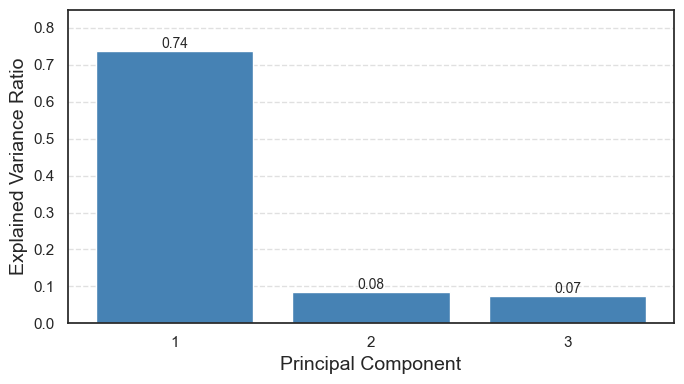

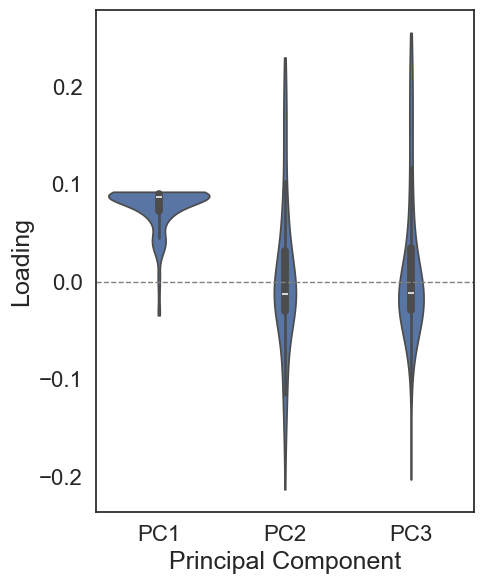

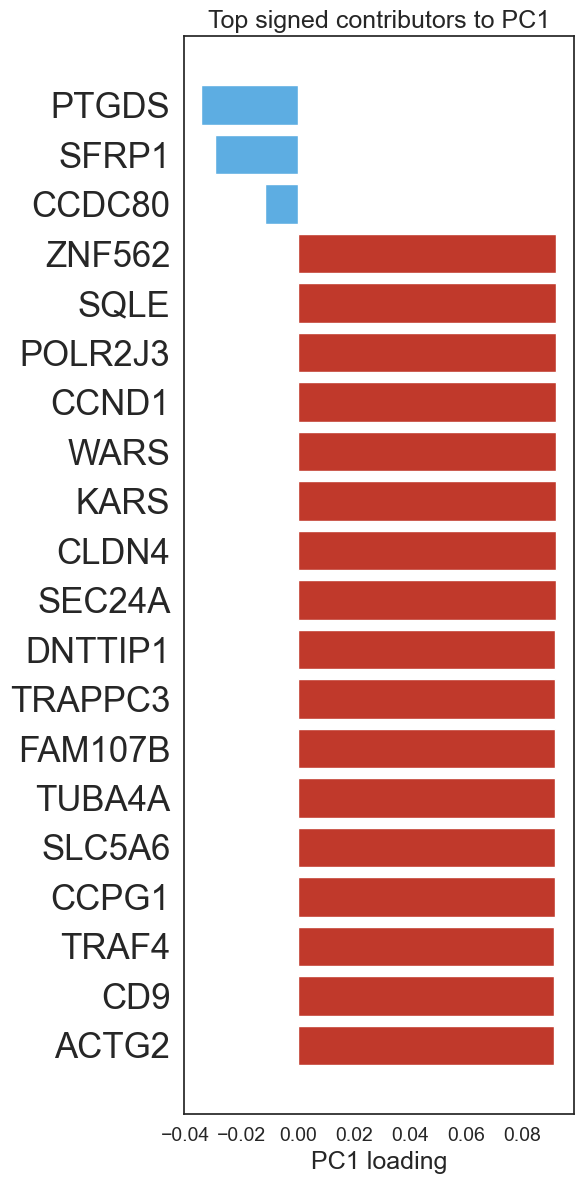

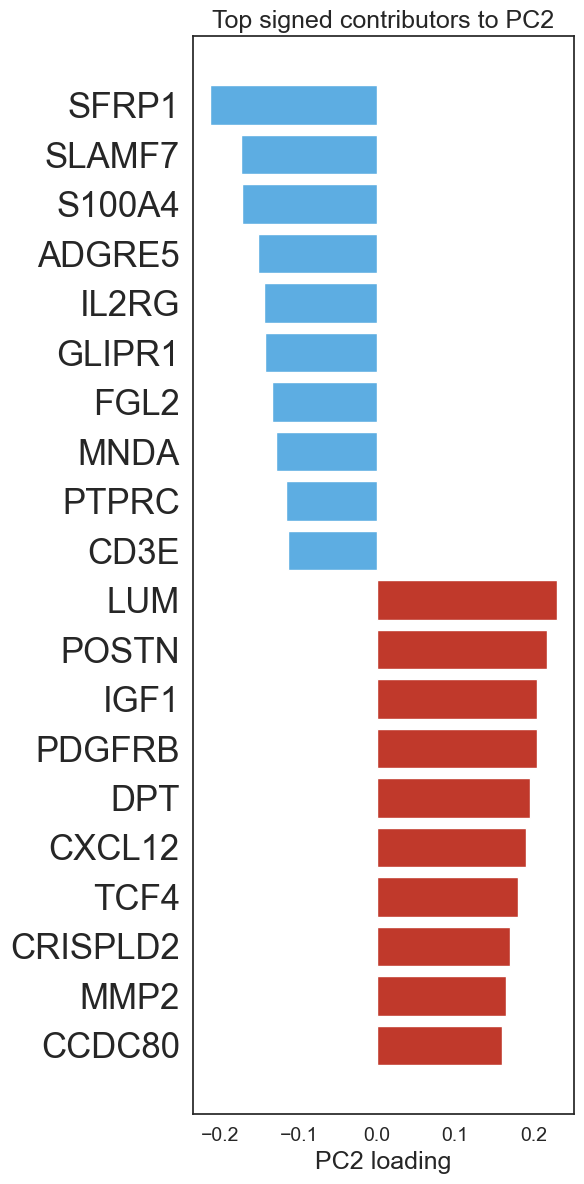

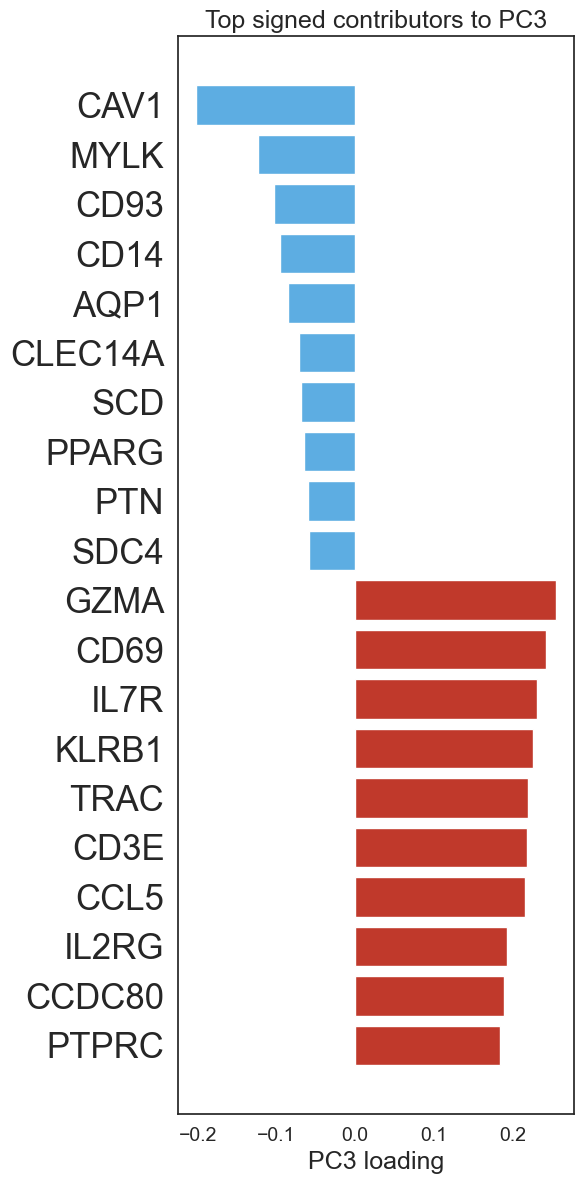

In [28]:
from scomv.spatial_deg import Spatial_DEG

report = Spatial_DEG(n_components=3, standardize=True).fit(
    feature_matrix,
    feature_names=list(new_dict.values())
)

sns.set_theme(style="white")

# 1) Cumulative explained variance
report.plot_explained_variance_bar(max_pc=10)

# 2) Violin plots of loadings (PC1–PC3)
report.plot_loading_violin(pcs=(0, 1, 2))

# 3) Signed top contributing genes for PC1, PC2, and PC3 (bar plots)
report.plot_signed_top_contributions_multi(pcs=(0, 1, 2), top_pos=10, top_neg=10)

# Retrieve top positively and negatively contributing genes
top_df = report.get_top_genes_signed(pcs=(0, 1, 2), top_pos=10, top_neg=10)

# Extract unique genes from the top contributors
top_pca_genes = top_df["gene"].drop_duplicates().tolist()

# Exclude PC1 and keep genes ranked within top 5
top_df = top_df[(top_df["PC"] != "PC1") & (top_df["rank"] <= 5)]

# Final list of top PCA-associated genes
top_pca_genes = top_df["gene"].drop_duplicates().tolist()

/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



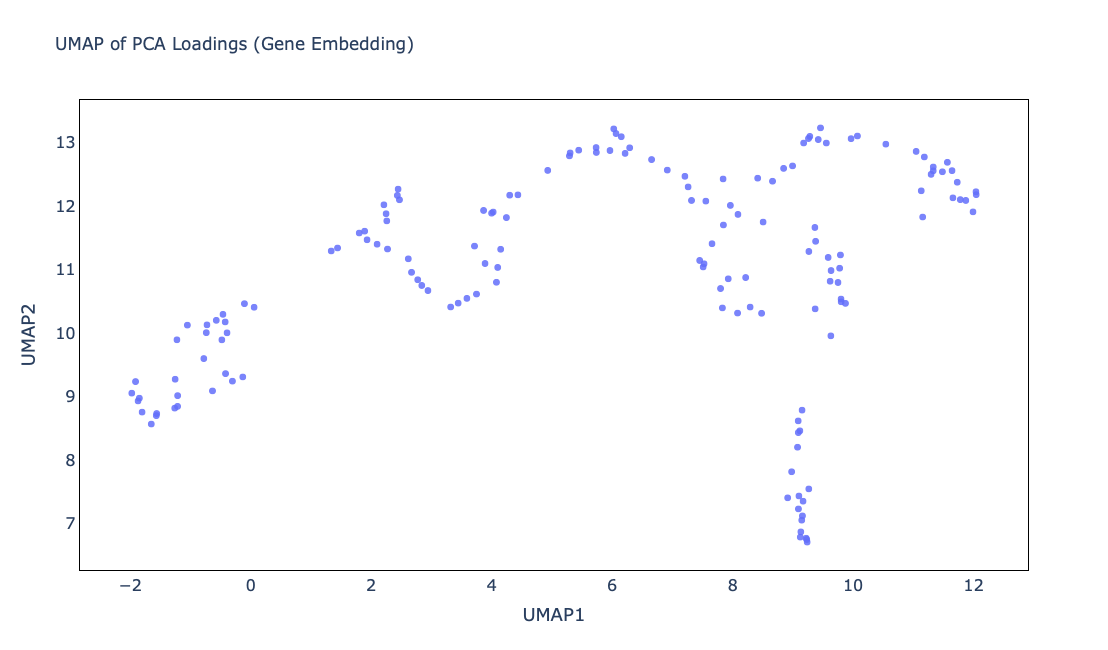

In [25]:
# Load the file containing spatial distribution annotations
annotation_path = "../tutorial_data/breast_gene_annotate.csv"
annotate_df = pd.read_csv(annotation_path)

## Label PCoA components
def add_info(clu_num, names, gene_name, doubt_info , selected_genes):
    if gene_name in selected_genes:
    #if gene_name in selected_genes:
        # Convert labels from 1–6 to 0-based indexing by subtracting 1
        index_ = int(clu_num) - 1
        names[index_].append(gene_name)


names = [[] for i in range(6)]
for i in range(annotate_df.shape[0]):
    clu_num = annotate_df.iloc[i, 1]
    if not clu_num ==  'NaN':
        gene_name = annotate_df.iloc[i, 0]
        doubt_info = annotate_df.iloc[i, 2]
        add_info(clu_num, names, gene_name, doubt_info, common_genes)

pheris = names[0]
print(f"pheri: {len(pheris)}")
insides = names[1]
print(f"inside: {len(insides)}")
lows = names[2]
print(f"low: {len(lows)}")
ubi_in = names[3]
print(f"ubi_in: {len(ubi_in)}")
ubi_out = names[4]
print(f"ubi_out: {len(ubi_out)}")

label_df = annotate_df.iloc[:, :2]
label_df.columns = ["label", "gene"]

for index_name in umap_df.index:
    if index_name in names[0]:
        umap_df.loc[index_name, 'annotation'] = "peripheral"
    elif index_name in names[1]:
        umap_df.loc[index_name, 'annotation'] = "internal"
    elif index_name in names[2]:
        umap_df.loc[index_name, 'annotation'] = "low"
    elif index_name in names[3]:
        umap_df.loc[index_name, 'annotation'] = "ubiquitous (include internal)"
    elif index_name in names[4]:
        umap_df.loc[index_name, 'annotation'] = "ubiquitous (not include internal)"


pheri: 54
inside: 39
low: 0
ubi_in: 43
ubi_out: 21
